   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)
0           1   56                  84                      64
1           2   69                  86                      49
2           3   46                  41                      17
3           4   32                  23                      44
4           5   60                  76                      92


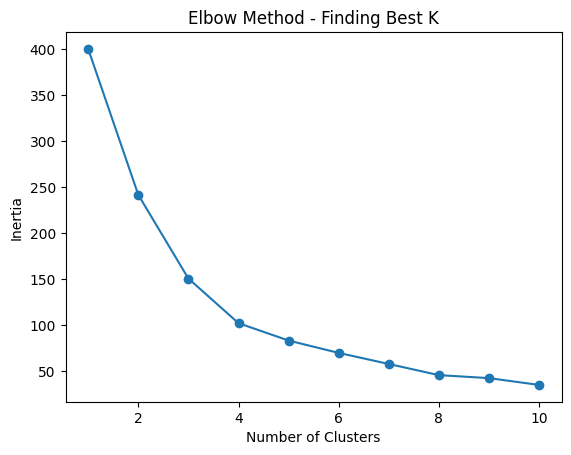

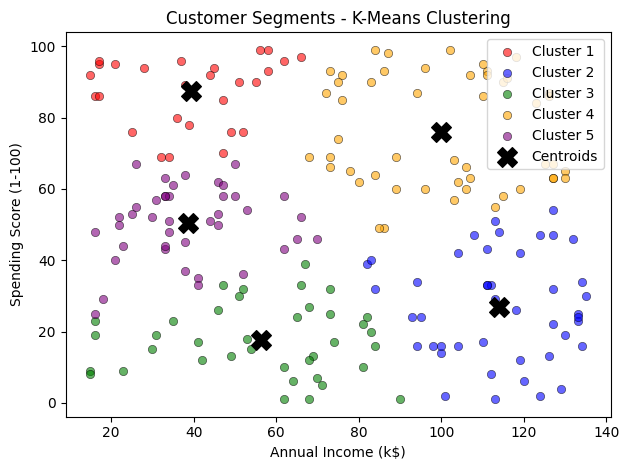

Done! 5 customer segments identified.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Create dataset
np.random.seed(42)
n = 200
customer_id = range(1, n+1)
age = np.random.randint(18, 70, n)
income = np.random.randint(15, 137, n)
spending_score = np.random.randint(1, 100, n)

df = pd.DataFrame({
    'CustomerID': customer_id,
    'Age': age,
    'Annual Income (k$)': income,
    'Spending Score (1-100)': spending_score
})
print(df.head())
# Scale the data
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.savefig('elbow_plot.png')
plt.show()
# Train KMeans with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Plot clusters
plt.figure()
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                        cluster_data['Spending Score (1-100)'],
                                        c=colors[i], label=f'Cluster {i+1}',
                                                        alpha=0.6, edgecolors='black', linewidths=0.5)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('Customer Segments - K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('customer_clusters.png')
plt.show()

print("Done! 5 customer segments identified.")